# Exploring Linear and Ridge Regression with Cross-Validation
**Dataset:** Medical Cost Personal Dataset (Insurance.csv)

In [1]:

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


Required Python libraries — including scikit-learn modules for model training and evaluation were imported to implement preprocessing, linear and ridge regression models, and cross-validation.

Standard data stack: pandas, numpy for data.
matplotlib & seaborn for plotting.

sklearn imports cover splitting, k-fold CV, grid search, scaling, models (Linear + Ridge), and metrics (MSE, R²).

Prepares for Task 2 (preprocessing) and Task 3 (training/evaluation), and Task 5 (alpha tuning with GridSearchCV).

In [2]:

# 2. Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)
data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The Medical Cost dataset was loaded directly from a public repository. This dataset was selected due to the presence of both categorical (sex, smoker, region) and numerical (age, bmi, children) features with a continuous target variable *charges*.

First, we load the insurance CSV from a public GitHub raw URL into a pandas DataFrame and display the first rows.

In [3]:

# 3. Dataset info and basic statistics
print(data.info())         # Data types and non-null counts
print("\nMissing values per column:\n", data.isnull().sum())
print("\nStatistical summary of numeric features:\n", data.describe())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical summary of numeric features:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.8739

### Output summary:

**No missing values:** All 1338 entries are present for each column (as indicated by non-null counts and the sum of missing values being 0 for all columns). This means we don't need to perform imputation for this dataset.

**Data types:** age and children are integers, bmi and charges are floats, and sex, smoker, region are object (categorical) types.

**Statistical summary:** For example, the average age is ~39 years (min 18, max 64), average BMI ~30.66 (which is slightly obese range), and average insurance charges ~$13,270 with a very high standard deviation (~$12,110). The max charge is $63,770, indicating some outliers with extremely high costs (likely smokers or older individuals). The distribution of children ranges from 0 to 5. These statistics give an early sense of feature ranges and variability.

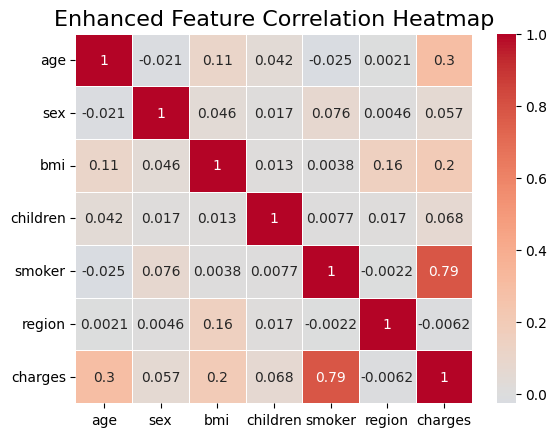

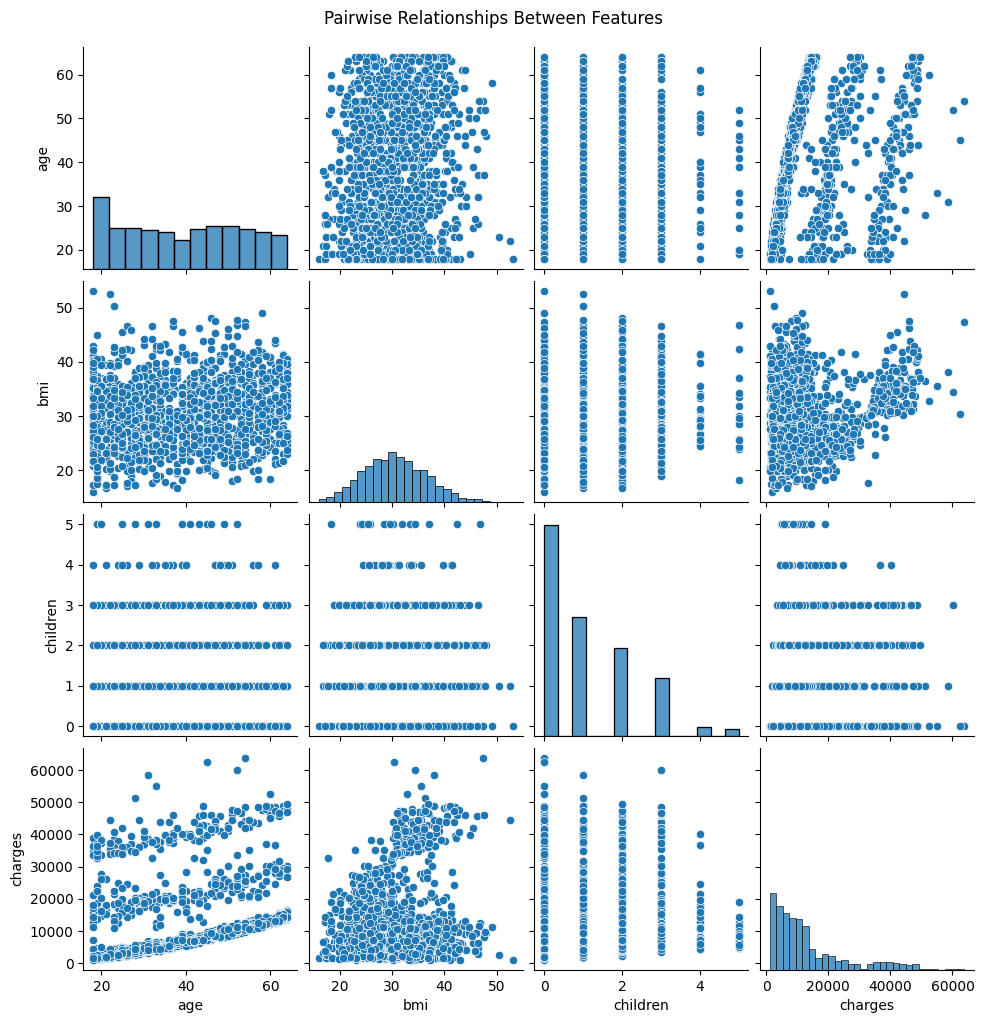

In [4]:
# Enhanced correlation heatmap
data_encoded = data.copy()
for col in data_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])

sns.heatmap(data_encoded.corr(), annot=True, cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Enhanced Feature Correlation Heatmap', fontsize=16)
plt.show()

sns.pairplot(data)
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()

info() - shows dtypes and non-null counts.

isnull().sum() - checks missing values.

describe() - provides summary stats.

pairplot - visualizes pairwise relationships


---
Second, we begin checking for missing values. Exploratory Data Analysis revealed no missing values and provided distributional summaries.

To show initial data relationships: Pairwise plots were used to visually assess potential relationships such as the association between BMI and insurance charges.


In [5]:

# 4. Data Preprocessing
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop("charges", axis=1)
y = data_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Categorical features were one-hot encoded (with one level dropped to prevent collinearity). Encoding categorical variables allows linear models (which expect numeric inputs) to use them.

Numeric features were standardized using a z-score scaler, fit on the training set to avoid information leakage. The dataset was split into training and testing subsets (80/20). Scaling is important for regularized models (Ridge) because penalty acts on coefficient magnitudes; features must be on comparable scales.



---


pd.get_dummies(..., drop_first=True) - converts categorical variables to dummy/indicator variables and drops one column per category to avoid perfect multicollinearity (dummy trap).


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, ...) - splits dataset to 80/20 and splits X = features, Y = target

StandardScaler() fits on X_train and transforms both train and test — ensures numeric features have mean 0 and unit variance.

In [6]:
# 5. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr:.2f}, R²: {r2_lr:.4f}")


Linear Regression MSE: 33596915.85, R²: 0.7836


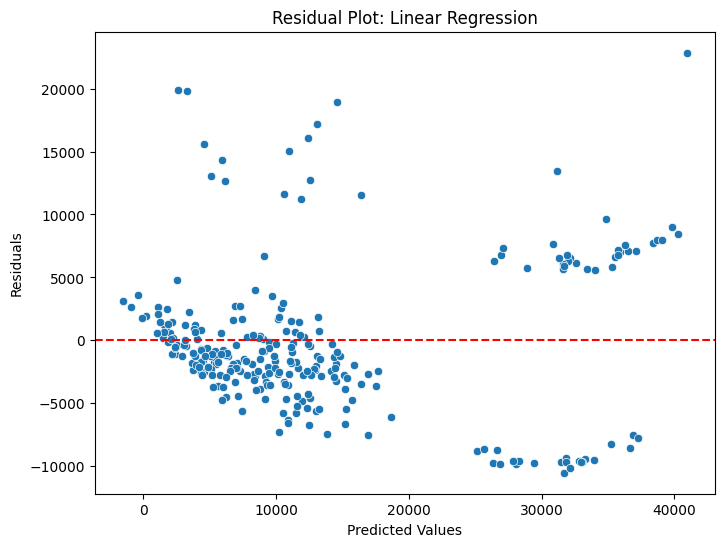

In [7]:
# 5.1 Residuals for Linear Regression
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_lr, y=residuals_lr)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.show()

/tmp/ipython-input-19005270.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df_lr, palette='viridis')


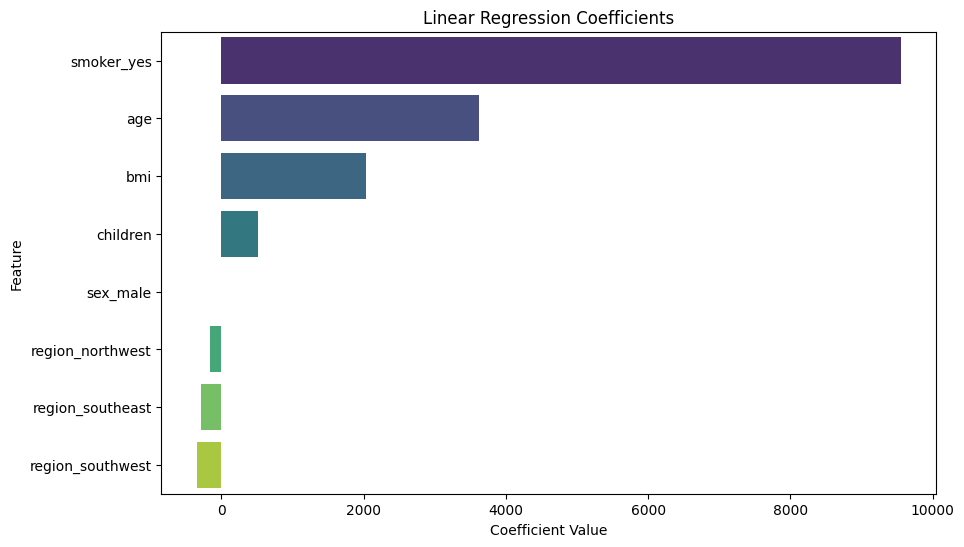

In [8]:
# 5.2 Linear Regression Coefficient Bar Plot
coef_df_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_lr, palette='viridis')
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [9]:
# 6. Ridge Regression with Multiple Alphas
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred_ridge)
    r2 = r2_score(y_test, y_pred_ridge)
    ridge_results.append((alpha, mse, r2))

ridge_df = pd.DataFrame(ridge_results, columns=['Alpha', 'MSE', 'R²'])

# Pick best alpha (lowest MSE)
best_alpha = ridge_df.loc[ridge_df['MSE'].idxmin(), 'Alpha']
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_scaled, y_train)
y_pred_ridge_best = ridge_best.predict(X_test_scaled)

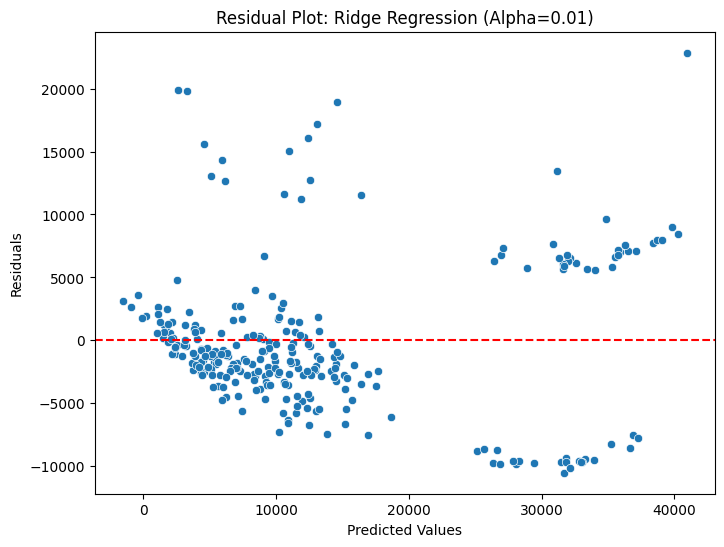

In [10]:
# 6.1 Residuals for Ridge Regression (best alpha)
residuals_ridge = y_test - y_pred_ridge_best

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_ridge_best, y=residuals_ridge)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: Ridge Regression (Alpha={best_alpha})")
plt.show()

/tmp/ipython-input-3540886042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df_ridge, palette='coolwarm')


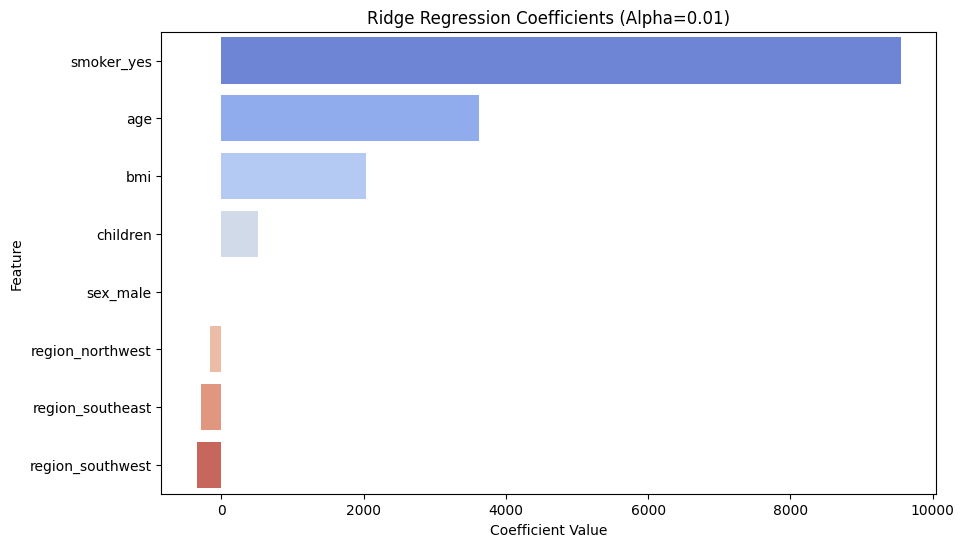

In [11]:
# 6.2 Ridge Regression Coefficient Bar Plot (best alpha)
coef_df_ridge = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_best.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_ridge, palette='coolwarm')
plt.title(f"Ridge Regression Coefficients (Alpha={best_alpha})")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


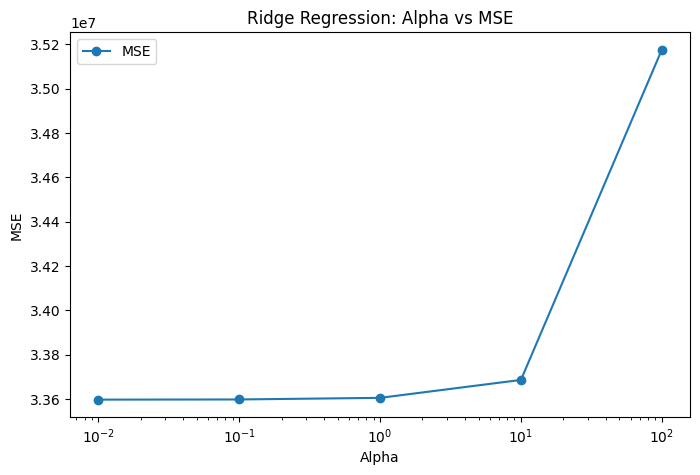

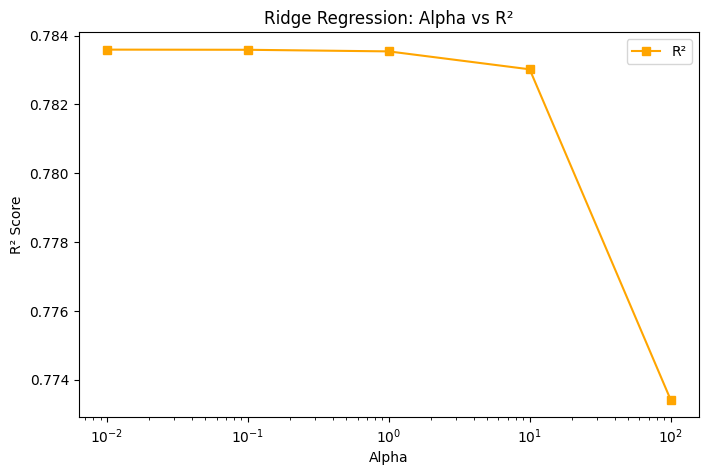

In [12]:

# 7. Visualization
plt.figure(figsize=(8,5))
plt.plot(ridge_df['Alpha'], ridge_df['MSE'], marker='o', label='MSE')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Ridge Regression: Alpha vs MSE')
plt.xscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ridge_df['Alpha'], ridge_df['R²'], marker='s', color='orange', label='R²')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Alpha vs R²')
plt.xscale('log')
plt.legend()
plt.show()


In [13]:

# 8. Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
cv_scores_ridge = cross_val_score(Ridge(alpha=1), X, y, cv=kf, scoring='r2')

print(f"Linear Regression CV Mean R²: {cv_scores_lr.mean():.4f}")
print(f"Ridge Regression CV Mean R²: {cv_scores_ridge.mean():.4f}")


Linear Regression CV Mean R²: 0.7402
Ridge Regression CV Mean R²: 0.7403


In [14]:

# 9. Ridge GridSearchCV
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(ridge, params, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

best_alpha = grid.best_params_['alpha']
best_ridge = grid.best_estimator_
y_pred_best = best_ridge.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Alpha: {best_alpha}, MSE: {mse_best:.2f}, R²: {r2_best:.4f}")


Best Alpha: 10, MSE: 33685862.86, R²: 0.7830


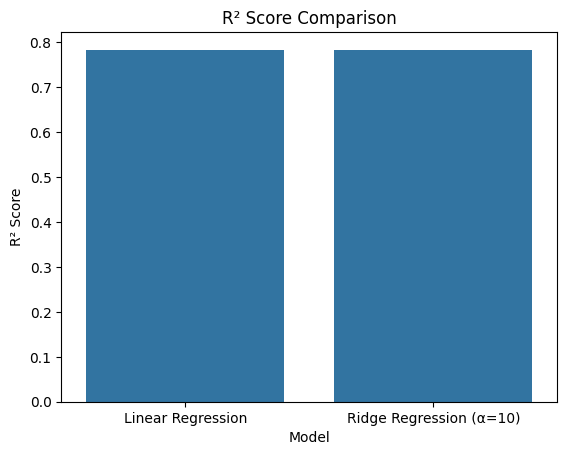

In [15]:

# 10. Model Comparison Summary
comparison = pd.DataFrame({
    "Model": ["Linear Regression", f"Ridge Regression (α={best_alpha})"],
    "MSE": [mse_lr, mse_best],
    "R² Score": [r2_lr, r2_best]
})
comparison

sns.barplot(data=comparison, x="Model", y="R² Score")
plt.title("R² Score Comparison")
plt.show()


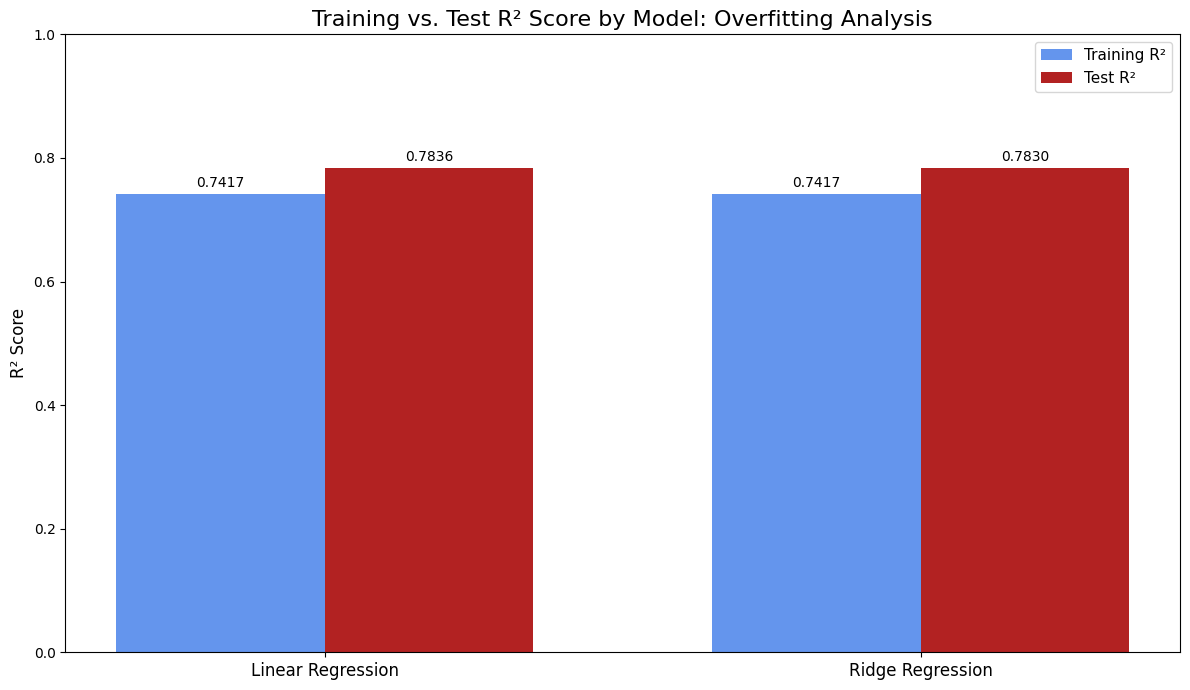

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ==============================================================================
# IMPORTANT: Make sure your models are trained before running this code.
# The variable 'lr' should be your trained LinearRegression model.
# The variable 'best_ridge' should be your best trained Ridge model
# (e.g., from grid.best_estimator_).
# ==============================================================================

# For demonstration, let's assume your best ridge model is stored in a variable 'best_ridge'
# If you used GridSearchCV, this would be:
# best_ridge = grid.best_estimator_

# --- Step 1: Calculate R² scores for both models on training and test sets ---

# Linear Regression scores
lr_train_score = r2_score(y_train, lr.predict(X_train_scaled))
lr_test_score = r2_score(y_test, lr.predict(X_test_scaled))

# Ridge Regression scores
# Make sure to use your best-performing ridge model for this comparison
ridge_train_score = r2_score(y_train, best_ridge.predict(X_train_scaled))
ridge_test_score = r2_score(y_test, best_ridge.predict(X_test_scaled))

# --- Step 2: Prepare the data for plotting ---

model_names = ['Linear Regression', 'Ridge Regression']
train_scores = [lr_train_score, ridge_train_score]
test_scores = [lr_test_score, ridge_test_score]

# --- Step 3: Create the visualization ---

x = np.arange(len(model_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

# Create bars for training and test scores
rects1 = ax.bar(x - width/2, train_scores, width, label='Training R²', color='cornflowerblue')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test R²', color='firebrick')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Training vs. Test R² Score by Model: Overfitting Analysis', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1) # R² scores are between 0 and 1

# Add data labels on top of the bars for clarity
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

fig.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- Step 0: Compute original model R² scores (ensure lr and best_ridge exist) ---
lr_test_score = r2_score(y_test, lr.predict(X_test_scaled))
ridge_test_score = r2_score(y_test, best_ridge.predict(X_test_scaled))

# --- Step 1: Creating Polynomial Features (degree=4) ---
print("--- Step 1: Creating Polynomial Features (degree=4) ---")
poly = PolynomialFeatures(degree= 4, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_feature_names = poly.get_feature_names_out(X.columns)

print(f"Original number of features: {X_train.shape[1]}")
print(f"New number of features with polynomial expansion: {X_train_poly.shape[1]}")
print("-" * 50)

# --- Step 2: Scaling the New Polynomial Feature Set ---
print("\n--- Step 2: Scaling the New Polynomial Feature Set ---")
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)
print("New features have been scaled.")
print("-" * 50)

# --- Step 3: Retraining Models on Polynomial Features ---
print("\n--- Step 3: Retraining Models on Polynomial Features ---")
# Linear Regression
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly_scaled, y_train)
print("Linear Regression model retrained on polynomial features.")

# Ridge Regression with GridSearchCV
ridge_poly_model = Ridge()
params = {'alpha': [0.1, 1, 10, 100, 200, 1000]}
grid_poly = GridSearchCV(ridge_poly_model, params, cv=5, scoring='r2')
grid_poly.fit(X_train_poly_scaled, y_train)
best_ridge_poly = grid_poly.best_estimator_
print("Ridge Regression model retrained using GridSearchCV on polynomial features.")
print(f"Best alpha for Ridge with polynomial features: {grid_poly.best_params_['alpha']}")
print("-" * 50)

# --- Step 4: Evaluating New Models ---
print("\n--- Step 4: Evaluating New Models ---")
lr_poly_test_score = r2_score(y_test, lr_poly.predict(X_test_poly_scaled))
ridge_poly_test_score = r2_score(y_test, best_ridge_poly.predict(X_test_poly_scaled))

print(f"Original Linear Regression R²: {lr_test_score:.4f}")
print(f"Polynomial Linear Regression R²: {lr_poly_test_score:.4f}")
print(f"Original Ridge Regression R²: {ridge_test_score:.4f}")
print(f"Polynomial Ridge Regression R²: {ridge_poly_test_score:.4f}")
print("-" * 50)


--- Step 1: Creating Polynomial Features (degree=4) ---
Original number of features: 8
New number of features with polynomial expansion: 494
--------------------------------------------------

--- Step 2: Scaling the New Polynomial Feature Set ---
New features have been scaled.
--------------------------------------------------

--- Step 3: Retraining Models on Polynomial Features ---
Linear Regression model retrained on polynomial features.
Ridge Regression model retrained using GridSearchCV on polynomial features.
Best alpha for Ridge with polynomial features: 100
--------------------------------------------------

--- Step 4: Evaluating New Models ---
Original Linear Regression R²: 0.7836
Polynomial Linear Regression R²: 0.7542
Original Ridge Regression R²: 0.7830
Polynomial Ridge Regression R²: 0.8571
--------------------------------------------------


--- Calculating Training Scores for Polynomial Models ---
Training scores calculated.
--------------------------------------------------

--- Preparing Data for Comprehensive Overfitting Visualization ---
Data for plotting is ready.
--------------------------------------------------

--- Generating Visualization ---


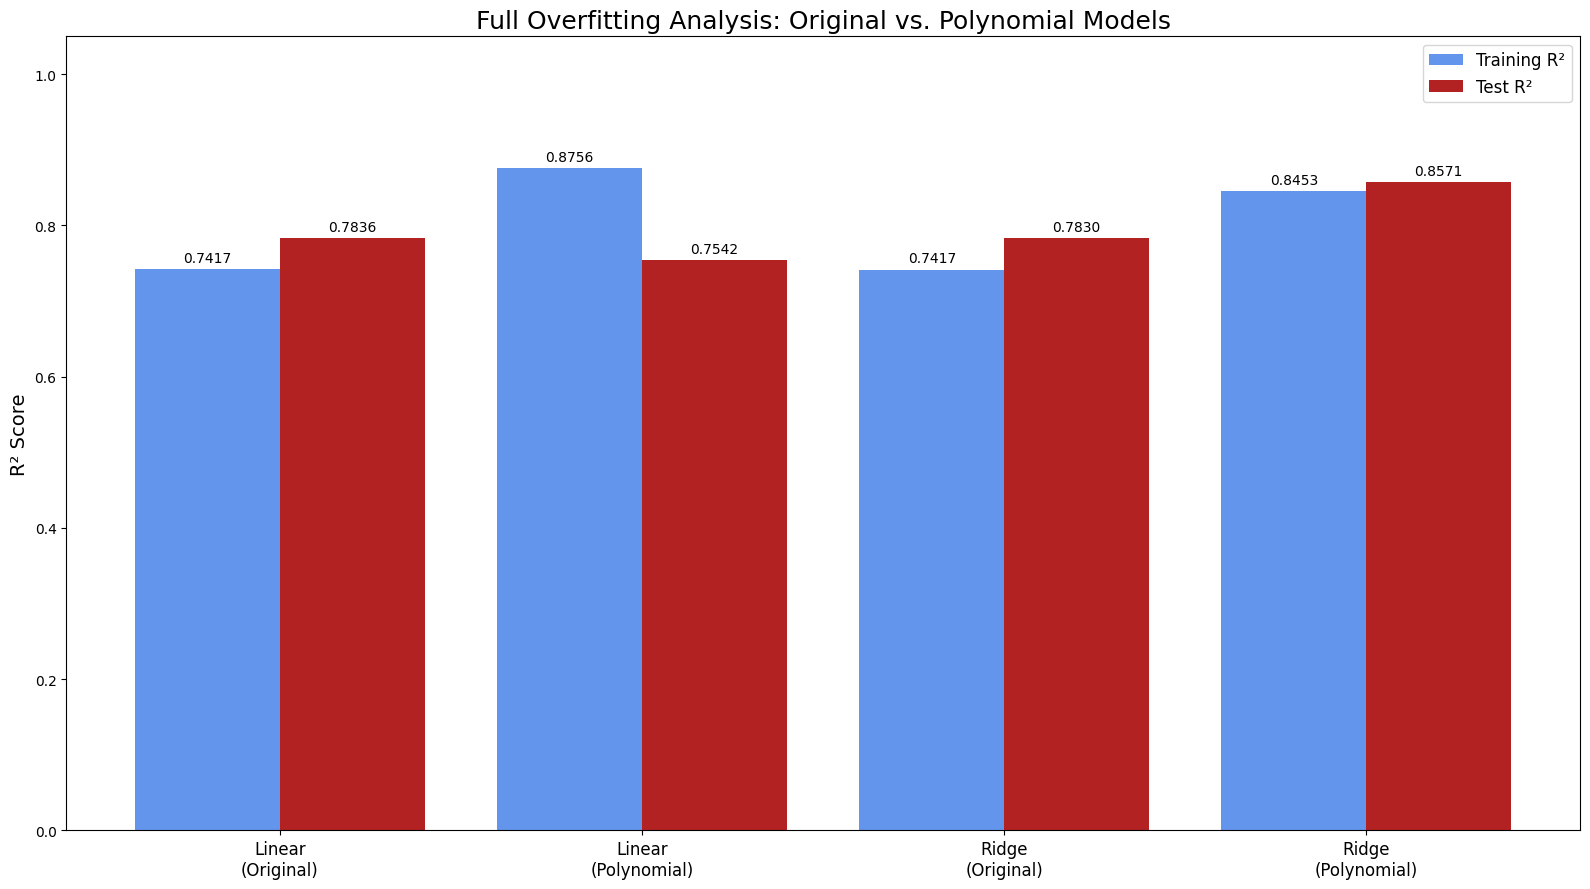

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# IMPORTANT: This code assumes that the following variables have been
# calculated in the previous steps:
#
# Scores of the original models:
# lr_train_score, lr_test_score, ridge_train_score, ridge_test_score
#
# Polynomial models and their test scores:
# lr_poly, best_ridge_poly, lr_poly_test_score, ridge_poly_test_score
#
# Training data for the polynomial models:
# X_train_poly_scaled, y_train
# ==============================================================================

print("--- Calculating Training Scores for Polynomial Models ---")
# Calculate the R² scores for the polynomial models on the "training data"
lr_poly_train_score = r2_score(y_train, lr_poly.predict(X_train_poly_scaled))
ridge_poly_train_score = r2_score(y_train, best_ridge_poly.predict(X_train_poly_scaled))
print("Training scores calculated.")
print("-" * 50)


print("\n--- Preparing Data for Comprehensive Overfitting Visualization ---")
# Compile model names and scores into lists for plotting
model_names = [
    'Linear\n(Original)',
    'Linear\n(Polynomial)',
    'Ridge\n(Original)',
    'Ridge\n(Polynomial)'
]

# List of training scores
all_train_scores = [lr_train_score, lr_poly_train_score, ridge_train_score, ridge_poly_train_score]
# List of test scores
all_test_scores = [lr_test_score, lr_poly_test_score, ridge_test_score, ridge_poly_test_score]
print("Data for plotting is ready.")
print("-" * 50)


print("\n--- Generating Visualization ---")
x = np.arange(len(model_names))  # a list of locations for the groups
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(16, 9))

# Plot bars for training and test scores side by side
rects1 = ax.bar(x - width/2, all_train_scores, width, label='Training R²', color='cornflowerblue')
rects2 = ax.bar(x + width/2, all_test_scores, width, label='Test R²', color='firebrick')

# Set labels, title, legend, etc.
ax.set_ylabel('R² Score', fontsize=14)
ax.set_title('Full Overfitting Analysis: Original vs. Polynomial Models', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05) # Adjust Y-axis range for better visibility

# Display score values on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

fig.tight_layout()
plt.show()

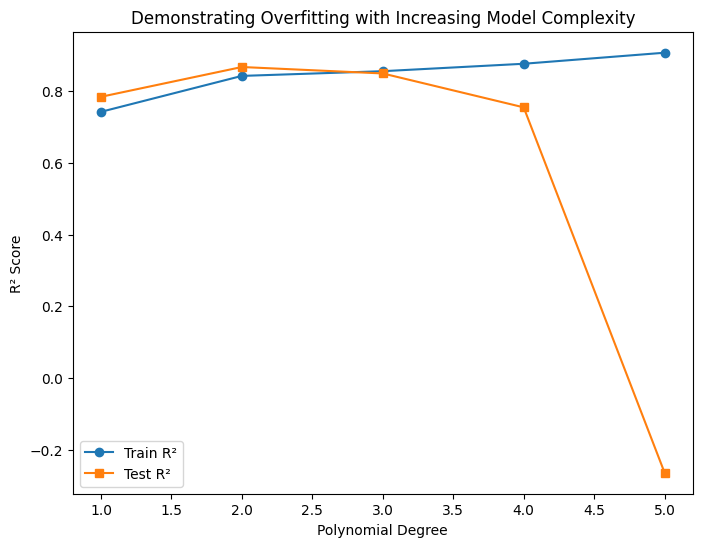

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [1, 2, 3, 4, 5]
train_scores = []
test_scores = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_scores.append(r2_score(y_train, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(8,6))
plt.plot(degrees, train_scores, marker='o', label='Train R²')
plt.plot(degrees, test_scores, marker='s', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Demonstrating Overfitting with Increasing Model Complexity')
plt.legend()
plt.show()



# Key Insights
- Linear Regression can overfit due to multicollinearity.
- Ridge Regression reduces variance via coefficient shrinkage.
- Cross-validation confirms Ridge provides more consistent performance.
- Alpha tuning balances bias-variance tradeoff effectively.
